In [1]:
import torch
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler

model_base = "CompVis/stable-diffusion-v1-4"
pipe = StableDiffusionPipeline.from_pretrained(model_base, torch_dtype=torch.float16)
pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)


/users/eleves-a/2025/iuliia.korotkova/EmotionalPortraitsGeneration/venv/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00, 11.52it/s]


## Baseline

In [3]:
pipe.to("cuda")

StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.35.2",
  "_name_or_path": "CompVis/stable-diffusion-v1-4",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    "stable_diffusion",
    "StableDiffusionSafetyChecker"
  ],
  "scheduler": [
    "diffusers",
    "DPMSolverMultistepScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

In [4]:
image = pipe("a portrait of a happy person", num_inference_steps=25).images[0]
image.save("output/images/happy_baseline.png")

100%|██████████| 25/25 [00:01<00:00, 20.36it/s]


## Fine-tuned model with LoRA

In [ ]:
model_path = "output/debug/pytorch_lora_weights.safetensors"

pipe.unet.load_attn_procs(model_path)
pipe.to("cuda");

In [4]:
image = pipe("happy", num_inference_steps=25).images[0]
image.save("output/images/happy.png")

100%|██████████| 25/25 [00:01<00:00, 18.88it/s]


In [ ]:
model_path = "/Data/iuliia.korotkova/output/output/exp_full/checkpoint-500/pytorch_lora_weights.safetensors"

pipe.unet.load_attn_procs(model_path)
pipe.to("cuda")

In [ ]:
emotions = {
    1: "surprise", 2: "fear", 3: "disgust",
    4: "happy", 5: "sad", 6: "anger", 7: "neutral"
}

for i, emotion in emotions.items():
    image = pipe(emotion, num_inference_steps=25).images[0]
    image.save(f"output/{emotion}_500.png")

In [ ]:
model_path = "/Data/iuliia.korotkova/output/exp_emoset/pytorch_lora_weights.safetensors"

pipe.unet.load_attn_procs(model_path)
pipe.to("cuda")

In [3]:
emotions = {
    "0": "amusement",
    "1": "awe",
    "2": "contentment",
    "3": "excitement",
    "4": "anger",
    "5": "disgust",
    "6": "fear",
    "7": "sadness"
  }

for i, emotion in emotions.items():
    image = pipe(emotion, num_inference_steps=25).images[0]
    image.save(f"output/{emotion}_emoset.png")

100%|██████████| 25/25 [00:01<00:00, 20.53it/s]


In [2]:
model_path = "/Data/iuliia.korotkova/output/exp_emoset_embed/pytorch_lora_weights.safetensors"

pipe.unet.load_attn_procs(model_path)
pipe.to("cuda");

/users/eleves-a/2025/iuliia.korotkova/EmotionalPortraitsGeneration/venv/lib64/python3.9/site-packages/diffusers/loaders/unet.py:214: FutureWarning: `load_attn_procs` is deprecated and will be removed in version 0.40.0. Using the `load_attn_procs()` method has been deprecated and will be removed in a future version. Please use `load_lora_adapter()`.
  deprecate("load_attn_procs", "0.40.0", deprecation_message)


In [ ]:
from torch import nn

emotion_embedding = nn.Embedding(8, pipe.text_encoder.config.hidden_size)
emotion_embedding.load_state_dict(torch.load('/Data/iuliia.korotkova/output/exp_emoset_embed/emotion_embedding.pth'))
emotion_embedding.eval()
emotion_embedding.to("cuda");

In [4]:
from train_text_to_image_lora import generate_with_emotion

  0%|          | 0/25 [00:00<?, ?it/s]

100%|██████████| 25/25 [00:01<00:00, 20.98it/s]


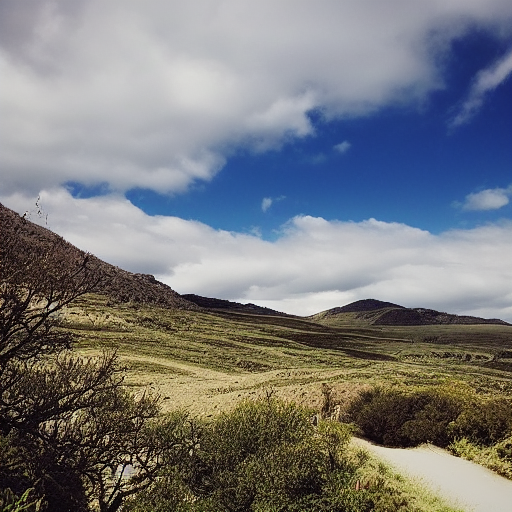

In [23]:
emotion_id = 4
prompt = "a photo of a landscape"

generate_with_emotion(pipe, emotion_embedding, prompt, emotion_id, num_inference_steps=25)